# Arbitrage Exploration and ML Detection
## Julia Dolce
### April 16, 2026

## Step 1: downloading necessary packages

In [4]:
#standard library
import sys
import time
import json
import csv
import asyncio
from pprint import pprint
from collections import defaultdict
from datetime import datetime, timezone
from pathlib import Path

#third-party libraries
import numpy as np
import pandas as pd
import requests
import websockets
import matplotlib.pyplot as plt
import seaborn as sns

#scikit-learn
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    TimeSeriesSplit
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    mean_squared_error, 
    r2_score
)
from sklearn.preprocessing import StandardScaler

#statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor

#CLOB client
from py_clob_client.clob_types import (
    OrderArgs,
    MarketOrderArgs,
    OrderType,
    OpenOrderParams,
    BalanceAllowanceParams,
    AssetType
)
from py_clob_client.order_builder.constants import BUY, SELL
from py_clob_client.exceptions import PolyApiException


# Step 2: Pulling Data From PolyMarket
### Github Links: 
https://github.com/CarlosIbCu/polymarket-kalshi-btc-arbitrage-bot/blob/main/backend/find_new_kalshi_market.py

https://github.com/RobotTraders/bits_and_bobs/blob/main/polymarket_python.ipynb

https://github.com/ashercn97/predmarket/blob/main/main.py

Notes about this section: 
Had a lot of difficulty with the live pipeline: I used the assistance of Claude and the three GitHub links above, as the PolyMarket API was restructured
as of March 31, 2026. 

Because Polymarket does not have a "category" section, I chose to define these myself with keywords that appeared often in the current prediction markets. I sorted into buckets labeled: politics, sports, geopolitics, culture, and crypto. If none matched my keywords, they were labeled other.  

CODE UPDATE Monday, April 6: Updated Category Pull limits, had an unproportional amount of sports markets compared to others


## Pulling $\bf{LIVE}$ data

In [7]:
#establish Config
GAMMA_API = "https://gamma-api.polymarket.com"
WS_URL = "wss://ws-subscriptions-clob.polymarket.com/ws/market"

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

RAW_CSV_PATH = DATA_DIR / "polymarket_microstructure_live.csv"
MARKET_UNIVERSE_CSV = DATA_DIR / "polymarket_market_universe.csv"

REQUEST_TIMEOUT = 20
MAX_MARKETS = 1000             
PING_INTERVAL_SECONDS = 10   
FLUSH_EVERY_N_ROWS = 250
ROTATE_SUBSCRIPTIONS_CHUNK = 500  
NEAR_ARB_THRESHOLD = 1.002

session = requests.Session()
session.headers.update({
    "User-Agent": "Mozilla/5.0",
    "Accept": "application/json",
})

In [8]:
#helper functions
def utc_now_iso():
    return datetime.now(timezone.utc).isoformat()

def safe_float(x):
    try:
        if x is None or x == "":
            return np.nan
        return float(x)
    except Exception:
        return np.nan

#handles Python lists and strings
def parse_jsonish_list(x):
    if isinstance(x, list):
        return x

    if isinstance(x, str):
        try:
            parsed = json.loads(x)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            pass

        stripped = x.strip().strip("[]")
        if not stripped:
            return []
        return [part.strip().strip('"').strip("'") for part in stripped.split(",")]

    return []

#normalized yes/no outcomes
def normalize_binary_market(market):
    outcomes = parse_jsonish_list(market.get("outcomes"))
    outcome_prices = parse_jsonish_list(market.get("outcomePrices"))
    token_ids = parse_jsonish_list(market.get("clobTokenIds"))

    if len(outcomes) != 2 or len(token_ids) != 2:
        return None

    pairs = []
    for i, label in enumerate(outcomes):
        label_clean = str(label).strip().lower()
        token = token_ids[i] if i < len(token_ids) else None
        price = outcome_prices[i] if i < len(outcome_prices) else None
        pairs.append({
            "label_clean": label_clean,
            "token_id": str(token) if token is not None else None,
            "outcome_price": safe_float(price),
        })

    yes = next((p for p in pairs if p["label_clean"] == "yes"), None)
    no = next((p for p in pairs if p["label_clean"] == "no"), None)

    if yes is None or no is None:
        return None

    return {
        "yes_token_id": yes["token_id"],
        "no_token_id": no["token_id"],
        "yes_outcome_price": yes["outcome_price"],
        "no_outcome_price": no["outcome_price"],
    }
def chunked(seq, size):
    for i in range(0, len(seq), size):
        yield seq[i:i + size]

In [9]:
#CATEGORY FUNCTION: 
# bucket terms were designed by me by looking at terms used in current markets. I have updated terms many times, and these seemed to recur the most
# Some subjects fit in multiple buckets, such as "Will there be a ceasefire before GTA VI), i established a priority order such that geopolitics 
# appears above pop-culture and etc. 

def simple_category(question):

    text = " ".join([str(question or "")]).lower()

    sports_terms = ["nba", "nfl", "mlb", "nhl", "wnba", "soccer", "football",
        "baseball", "basketball", "tennis", "golf", "ufc", "super bowl", 
        "world series", "stanley cup", "finals", "fifa", "world cup"]
    
    politics_terms = ["president", "senate", "house", "election", "governor",
        "democrat", "republican", "white house", "trump", "biden"]
    
    crypto_terms = ["bitcoin", "btc", "ethereum", "eth", "solana", "crypto", "doge"]
    
    culture_terms = ["movie", "album", "grammy", "oscar", "emmy", "celebrity",
        "tv", "box office", "actor", "actress", "gta vi", "weinstein",
        "eurovision", "elon", "musk", "mrbeast"]
    
    geopolitics_terms = ["china", "taiwan", "russia", "ukraine", "war",
    "conflict", "ceasefire", "invasion", "military", "nato"]
    
    if any(t in text for t in geopolitics_terms):
        return "geopolitics"
    if any(t in text for t in politics_terms):
        return "politics"
    if any(t in text for t in crypto_terms):
        return "crypto"
    if any(t in text for t in culture_terms):
        return "pop_culture"
    if any(t in text for t in sports_terms):
        return "sports"

    return "other"

In [10]:
#market discovery: fetching live markets
def fetch_active_markets(limit=500, max_pages=30):

    all_markets = []
    offset = 0

    for page in range(max_pages):
        params = {
            "active": "true",
            "closed": "false",
            "limit": limit,
            "offset": offset,
        }

        r = session.get(
            f"{GAMMA_API}/markets",
            params=params,
            timeout=REQUEST_TIMEOUT,
        )
        r.raise_for_status()
        batch = r.json()

        if not batch:
            break

        all_markets.extend(batch)
        print(f"Fetched {len(batch)} markets at offset {offset}")

        if len(batch) < limit:
            break

        offset += limit

    print(f"Total raw markets fetched: {len(all_markets)}")
    return all_markets

#building market universe: update made, limiting how much data can be pulled in each
def build_market_universe(
    max_markets=MAX_MARKETS,
    per_category_caps=None,
    min_liquidity=0,
    min_volume_24hr=0
):
    raw_markets = fetch_active_markets(limit=500, max_pages=20)

    if per_category_caps is None:
        per_category_caps = {
            "sports": 100,
            "politics": 150,
            "geopolitics": 150,
            "crypto": 200,
            "pop_culture": 150,
            "other": 10,
        }

    rows = []
    for m in raw_markets:
        if m.get("active") is not True:
            continue
        if m.get("closed") is True:
            continue
        if m.get("archived") is True:
            continue
        if m.get("enableOrderBook") is not True:
            continue

        parsed = normalize_binary_market(m)
        if parsed is None:
            continue

        liquidity_num = safe_float(m.get("liquidityNum"))
        volume_24hr = safe_float(m.get("volume24hr"))

        if pd.notna(liquidity_num) and liquidity_num < min_liquidity:
            continue
        if pd.notna(volume_24hr) and volume_24hr < min_volume_24hr:
            continue

        rows.append({
            "market_id": m.get("id"),
            "question": m.get("question"),
            "slug": m.get("slug"),
            "url": f"https://polymarket.com/event/{m.get('slug')}" if m.get("slug") else None,
            "condition_id": m.get("conditionId"),
            "category": m.get("category"),
            "subcategory": m.get("subcategory"),
            "series_slug": m.get("seriesSlug"),
            "event_slug": m.get("eventSlug"),
            "description": m.get("description"),
            "start_date": m.get("startDate"),
            "end_date": m.get("endDate"),
            "liquidity_num": safe_float(m.get("liquidityNum")),
            "volume_24hr": safe_float(m.get("volume24hr")),
            "volume_num": safe_float(m.get("volumeNum")),
            "yes_token_id": parsed["yes_token_id"],
            "no_token_id": parsed["no_token_id"],
            "yes_outcome_price": parsed["yes_outcome_price"],
            "no_outcome_price": parsed["no_outcome_price"],
        })

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    df = df.drop_duplicates(subset=["market_id"]).reset_index(drop=True)

    df["category_guess"] = df.apply(
        lambda r: simple_category(question=r["question"]),
        axis=1,
    )
    df["category_manual"] = np.nan

    df["category_final"] = df["category_manual"].fillna(df["category_guess"])

    #CHANGE MADE HERE HALFWAY THROUGH TO BALANCE MARKETS BETTER
    df = df.sort_values(
        ["category_final", "liquidity_num", "volume_24hr"],
        ascending=[True, False, False]
    )

    category_caps = {
        "sports": 100,
        "politics": 250,
        "geopolitics": 250,
        "crypto": 100,
        "pop_culture": 250,
        "other": 50
    }
    
    selected = []
    for cat, cap in category_caps.items():
        selected.append(df[df["category_final"] == cat].head(cap))

    df = pd.concat(selected, ignore_index=True)

    # NEW: final cap in case total is still too big
    df = df.head(max_markets).reset_index(drop=True)

    df.to_csv(MARKET_UNIVERSE_CSV, index=False)
    print(f"Saved market universe to {MARKET_UNIVERSE_CSV}")
    print(f"Markets in universe: {len(df)}")
    print(df["category_final"].value_counts())

    return df

In [11]:
class LiveMarketState:
    def __init__(self, markets_df: pd.DataFrame):
        self.market_meta = {}
        self.token_to_market_side = {}

        self.state = defaultdict(lambda: {
            "yes_bid": np.nan,
            "yes_ask": np.nan,
            "yes_bid_size": np.nan,
            "yes_ask_size": np.nan,
            "no_bid": np.nan,
            "no_ask": np.nan,
            "no_bid_size": np.nan,
            "no_ask_size": np.nan,
            "last_trade_price": np.nan,
            "last_trade_side_token": None,
            "last_event_type": None,
            "last_event_ts": None,
        })

        for _, row in markets_df.iterrows():
            market_id = row["market_id"]
            self.market_meta[market_id] = row.to_dict()

            self.token_to_market_side[str(row["yes_token_id"])] = (market_id, "yes")
            self.token_to_market_side[str(row["no_token_id"])] = (market_id, "no")

    def update_from_best_bid_ask(self, asset_id, bid, ask, bid_size=np.nan, ask_size=np.nan, event_type="best_bid_ask"):
        key = str(asset_id)
        if key not in self.token_to_market_side:
            return None

        market_id, side = self.token_to_market_side[key]
        s = self.state[market_id]

        if side == "yes":
            s["yes_bid"] = safe_float(bid)
            s["yes_ask"] = safe_float(ask)
            s["yes_bid_size"] = safe_float(bid_size)
            s["yes_ask_size"] = safe_float(ask_size)
        else:
            s["no_bid"] = safe_float(bid)
            s["no_ask"] = safe_float(ask)
            s["no_bid_size"] = safe_float(bid_size)
            s["no_ask_size"] = safe_float(ask_size)

        s["last_event_type"] = event_type
        s["last_event_ts"] = utc_now_iso()

        return self.make_row(market_id)

    def update_from_book(self, asset_id, bids, asks, event_type="book"):
        """
        bids/asks expected as lists of dicts with price/size.
        """
        best_bid = np.nan
        best_bid_size = np.nan
        best_ask = np.nan
        best_ask_size = np.nan

        if bids:
            valid_bids = []
            for x in bids:
                px = safe_float(x.get("price"))
                sz = safe_float(x.get("size"))
                if pd.notna(px):
                    valid_bids.append((px, sz))
            if valid_bids:
                best_bid, best_bid_size = max(valid_bids, key=lambda t: t[0])

        if asks:
            valid_asks = []
            for x in asks:
                px = safe_float(x.get("price"))
                sz = safe_float(x.get("size"))
                if pd.notna(px):
                    valid_asks.append((px, sz))
            if valid_asks:
                best_ask, best_ask_size = min(valid_asks, key=lambda t: t[0])

        return self.update_from_best_bid_ask(
            asset_id=asset_id,
            bid=best_bid,
            ask=best_ask,
            bid_size=best_bid_size,
            ask_size=best_ask_size,
            event_type=event_type,
        )

    def update_from_trade(self, asset_id, trade_price, event_type="last_trade_price"):
        key = str(asset_id)
        if key not in self.token_to_market_side:
            return None

        market_id, side = self.token_to_market_side[key]
        s = self.state[market_id]
        s["last_trade_price"] = safe_float(trade_price)
        s["last_trade_side_token"] = side
        s["last_event_type"] = event_type
        s["last_event_ts"] = utc_now_iso()

        return self.make_row(market_id)

    def make_row(self, market_id):
        meta = self.market_meta[market_id]
        s = self.state[market_id]

        yes_bid = s["yes_bid"]
        yes_ask = s["yes_ask"]
        no_bid = s["no_bid"]
        no_ask = s["no_ask"]

        yes_mid = np.nan if pd.isna(yes_bid) or pd.isna(yes_ask) else (yes_bid + yes_ask) / 2
        no_mid = np.nan if pd.isna(no_bid) or pd.isna(no_ask) else (no_bid + no_ask) / 2

        buy_both_cost = np.nan if pd.isna(yes_ask) or pd.isna(no_ask) else yes_ask + no_ask
        sell_both_revenue = np.nan if pd.isna(yes_bid) or pd.isna(no_bid) else yes_bid + no_bid

        spread_yes = np.nan if pd.isna(yes_bid) or pd.isna(yes_ask) else yes_ask - yes_bid
        spread_no = np.nan if pd.isna(no_bid) or pd.isna(no_ask) else no_ask - no_bid

        parity_mid_sum = np.nan if pd.isna(yes_mid) or pd.isna(no_mid) else yes_mid + no_mid
        distance_from_parity = np.nan if pd.isna(parity_mid_sum) else abs(parity_mid_sum - 1.0)

        edge = np.nan if pd.isna(buy_both_cost) else 1.0 - buy_both_cost
        sell_edge = np.nan if pd.isna(sell_both_revenue) else sell_both_revenue - 1.0

        row = {
            "timestamp_utc": s["last_event_ts"],
            "market_id": market_id,
            "question": meta.get("question"),
            "slug": meta.get("slug"),

            "category_final": meta.get("category_final"),

            "liquidity_num": meta.get("liquidity_num"),
            "volume_24hr": meta.get("volume_24hr"),
            "start_date": meta.get("start_date"),
            "end_date": meta.get("end_date"),

            "yes_token_id": meta.get("yes_token_id"),
            "no_token_id": meta.get("no_token_id"),

            "yes_bid": yes_bid,
            "yes_ask": yes_ask,
            "yes_bid_size": s["yes_bid_size"],
            "yes_ask_size": s["yes_ask_size"],

            "no_bid": no_bid,
            "no_ask": no_ask,
            "no_bid_size": s["no_bid_size"],
            "no_ask_size": s["no_ask_size"],

            "yes_mid": yes_mid,
            "no_mid": no_mid,

            "spread_yes": spread_yes,
            "spread_no": spread_no,
            "spread_total": np.nan if pd.isna(spread_yes) or pd.isna(spread_no) else spread_yes + spread_no,

            "buy_both_cost": buy_both_cost,
            "sell_both_revenue": sell_both_revenue,
            "edge": edge,
            "sell_edge": sell_edge,

            "mid_sum": parity_mid_sum,
            "distance_from_parity": distance_from_parity,

            "buy_both_arb": bool(pd.notna(buy_both_cost) and buy_both_cost < 1.0),
            "sell_both_arb": bool(pd.notna(sell_both_revenue) and sell_both_revenue > 1.0),
            "near_arb": bool(pd.notna(buy_both_cost) and buy_both_cost <= NEAR_ARB_THRESHOLD),

            "last_trade_price": s["last_trade_price"],
            "last_trade_side_token": s["last_trade_side_token"],
            "event_type": s["last_event_type"],
        }

        #other ML features
        row["imbalance_yes"] = (
            np.nan if pd.isna(s["yes_bid_size"]) or pd.isna(s["yes_ask_size"]) or (s["yes_bid_size"] + s["yes_ask_size"] == 0)
            else (s["yes_bid_size"] - s["yes_ask_size"]) / (s["yes_bid_size"] + s["yes_ask_size"])
        )
        row["imbalance_no"] = (
            np.nan if pd.isna(s["no_bid_size"]) or pd.isna(s["no_ask_size"]) or (s["no_bid_size"] + s["no_ask_size"] == 0)
            else (s["no_bid_size"] - s["no_ask_size"]) / (s["no_bid_size"] + s["no_ask_size"])
        )

        return row

In [12]:
#Class for CSV writer
class CsvBatchWriter:
    def __init__(self, path: Path, flush_every_n_rows=FLUSH_EVERY_N_ROWS):
        self.path = path
        self.flush_every_n_rows = flush_every_n_rows
        self.buffer = []
        self.header_written = path.exists() and path.stat().st_size > 0

    def add(self, row):
        if row is None:
            return
        self.buffer.append(row)
        if len(self.buffer) >= self.flush_every_n_rows:
            self.flush()

    def flush(self):
        if not self.buffer:
            return

        df = pd.DataFrame(self.buffer)

        mode = "a" if self.header_written else "w"
        df.to_csv(self.path, mode=mode, index=False, header=not self.header_written)

        self.header_written = True
        print(f"Flushed {len(df)} rows to {self.path}")
        self.buffer.clear()

In [14]:
async def send_heartbeat(ws):
    while True:
        await asyncio.sleep(PING_INTERVAL_SECONDS)
        try:
            await ws.send("PING")
        except Exception:
            return

#subscribe in chunks in case the asset list gets large
async def subscribe_in_chunks(ws, asset_ids):
    total = 0
    for chunk in chunked(asset_ids, ROTATE_SUBSCRIPTIONS_CHUNK):
        msg = {
            "assets_ids": chunk,
            "type": "market",
            "custom_feature_enabled": True,
        }
        await ws.send(json.dumps(msg))
        total += len(chunk)
        await asyncio.sleep(0.2)

    print(f"Subscribed to {total} asset IDs")

#some WS integrations emit single dicts, others lists.
def normalize_message_payload(raw_message):
    try:
        msg = json.loads(raw_message)
    except json.JSONDecodeError:
        return []

    if isinstance(msg, list):
        return msg
    if isinstance(msg, dict):
        return [msg]
    return []

async def run_live_collector(markets_df: pd.DataFrame):
    if markets_df.empty:
        print("No markets to track.")
        return

    asset_ids = []
    for _, row in markets_df.iterrows():
        asset_ids.append(str(row["yes_token_id"]))
        asset_ids.append(str(row["no_token_id"]))

    state = LiveMarketState(markets_df)
    writer = CsvBatchWriter(RAW_CSV_PATH)

    print(f"Opening WebSocket: {WS_URL}")
    async with websockets.connect(
        WS_URL,
        ping_interval=None,   # use app-level heartbeat
        max_size=10_000_000,
        open_timeout=30,
        close_timeout=30,
    ) as ws:
        await subscribe_in_chunks(ws, asset_ids)
        hb_task = asyncio.create_task(send_heartbeat(ws))

        msg_count = 0
        row_count = 0

        try:
            async for raw in ws:
                if raw == "PONG":
                    continue

                payloads = normalize_message_payload(raw)
                if not payloads:
                    continue

                for item in payloads:
                    msg_count += 1

                    event_type = item.get("event_type") or item.get("type")

                    # best bid/ask update
                    if event_type == "best_bid_ask":
                        asset_id = item.get("asset_id") or item.get("assetId") or item.get("asset")
                        bid = item.get("best_bid") or item.get("bid")
                        ask = item.get("best_ask") or item.get("ask")
                        bid_size = item.get("best_bid_size") or item.get("bid_size")
                        ask_size = item.get("best_ask_size") or item.get("ask_size")

                        row = state.update_from_best_bid_ask(
                            asset_id=asset_id,
                            bid=bid,
                            ask=ask,
                            bid_size=bid_size,
                            ask_size=ask_size,
                            event_type="best_bid_ask",
                        )
                        if row is not None:
                            row_count += 1
                            writer.add(row)

                    #full book snapshot
                    elif event_type == "book":
                        asset_id = item.get("asset_id") or item.get("assetId") or item.get("asset")
                        bids = item.get("bids", []) or []
                        asks = item.get("asks", []) or []

                        row = state.update_from_book(
                            asset_id=asset_id,
                            bids=bids,
                            asks=asks,
                            event_type="book",
                        )
                        if row is not None:
                            row_count += 1
                            writer.add(row)

                    #price_change: some payloads may include best quotes or changed levels
                    elif event_type == "price_change":
                        asset_id = item.get("asset_id") or item.get("assetId") or item.get("asset")

                        # try direct best quote fields first
                        bid = item.get("best_bid") or item.get("bid")
                        ask = item.get("best_ask") or item.get("ask")
                        bid_size = item.get("best_bid_size") or item.get("bid_size")
                        ask_size = item.get("best_ask_size") or item.get("ask_size")

                        if bid is not None or ask is not None:
                            row = state.update_from_best_bid_ask(
                                asset_id=asset_id,
                                bid=bid,
                                ask=ask,
                                bid_size=bid_size,
                                ask_size=ask_size,
                                event_type="price_change",
                            )
                            if row is not None:
                                row_count += 1
                                writer.add(row)

                    #last trade price
                    elif event_type == "last_trade_price":
                        asset_id = item.get("asset_id") or item.get("assetId") or item.get("asset")
                        trade_price = item.get("price") or item.get("last_trade_price")

                        row = state.update_from_trade(
                            asset_id=asset_id,
                            trade_price=trade_price,
                            event_type="last_trade_price",
                        )
                        if row is not None:
                            row_count += 1
                            writer.add(row)

                    #ignore other message types
                if msg_count % 500 == 0:
                    print(f"Messages processed: {msg_count:,} | Rows collected: {row_count:,}")

        finally:
            hb_task.cancel()
            writer.flush()

In [15]:
#Call main in notebook(addded all functions to one notebook rather than referencing files for ease of access)
async def main(
    max_markets=MAX_MARKETS,
    per_category_caps=None,
    min_liquidity=0,
    min_volume_24hr=0
):
    if per_category_caps is None:
        per_category_caps = {
            "sports": 100,
            "politics": 250,
            "geopolitics": 250,
            "crypto": 200,
            "pop_culture": 250,
            "other": 50,
        }

    

    markets_df = build_market_universe(
        max_markets=max_markets,
        per_category_caps=per_category_caps,
        min_liquidity=min_liquidity,
        min_volume_24hr=min_volume_24hr
    )

    if markets_df.empty:
        print("No eligible binary markets found.")
        return None

    print("\nCategory counts:")
    print(markets_df["category_final"].value_counts(dropna=False).to_string())

    print("\nSample tracked markets:")
    print(
        markets_df[[
            "market_id", "question",
            "category_final", "volume_24hr", "liquidity_num"
        ]].head(20).to_string(index=False)
    )

    print("\nStarting live collector...")
    print(f"Output CSV: {RAW_CSV_PATH}")

    await run_live_collector(markets_df)
    return markets_df

In [16]:
#adding data to CSV- uncomment to run live websocket
#markets_df = await main(max_markets=1000)

# Step 3: Cleaning Data, and Grouping/Sorting Values 

In [18]:
df = pd.read_csv('data/polymarket_microstructure_live.csv')
print(f"Rows in CSV: {len(df)}")

Rows in CSV: 1165310


In [19]:
#must have bids in them!
df = df[
    df[["yes_bid", "yes_ask", "no_bid", "no_ask"]]
    .notna()
    .any(axis=1)
]

#prices between 0 and 1
df = df[
    (df["yes_ask"].between(0, 1)) &
    (df["no_ask"].between(0, 1))
]

#make sure liquid and volume:
df = df[
    ~(
        (df["liquidity_num"] == 0) &
        (df["volume_24hr"] == 0)
    )
]

#making sure all categories are objects
df["category_final"] = df["category_final"].astype("object")

print(f"Rows in CSV: {len(df)}")

Rows in CSV: 1158202


In [20]:
#sort by market id 
df = df.sort_values(["market_id", "timestamp_utc"])

In [21]:
#volatility per market 
df["mid_price"] = df["yes_mid"] 

df["mid_return"] = (
    df.groupby("market_id")["mid_price"]
    .pct_change()
)

df["volatility_10"] = (
    df.groupby("market_id")["mid_return"]
    .rolling(10)
    .std()
    .reset_index(level=0, drop=True)
)

/var/folders/c5/ksdj80g92ydcskcqfb5cvj840000gn/T/ipykernel_48427/1319226213.py:6: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change()


In [22]:
#spread dynamics
df["spread_change"] = (
    df.groupby("market_id")["spread_total"]
    .diff()
)

df["spread_volatility"] = (
    df.groupby("market_id")["spread_total"]
    .rolling(10)
    .std()
    .reset_index(level=0, drop=True)
)

In [23]:
# imbalance shifts: signs of market inefficiency 
df["imbalance_change"] = (
    df.groupby("market_id")["imbalance_yes"]
    .diff()
    .rolling(5)
    .mean()
)

# Step 4: EDA and Data Exploration 

In [25]:
print("First 10 rows of the dataset:")
df.head(10)

First 10 rows of the dataset:


,timestamp_utc,market_id,question,slug,category_final,liquidity_num,volume_24hr,start_date,end_date,yes_token_id,...,last_trade_side_token,event_type,imbalance_yes,imbalance_no,mid_price,mid_return,volatility_10,spread_change,spread_volatility,imbalance_change
34,2026-04-03 18:00:06.545595+00:00,540816,Russia-Ukraine Ceasefire before GTA VI?,russia-ukraine-ceasefire-before-gta-vi-554,geopolitics,53602.798,1286.873689,2025-05-02T15:48:00.174Z,2026-07-31T12:00:00Z,8501497159083948713316135768103773293754490207...,...,NaN,book,0.084493,-0.084493,0.535,NaN,NaN,NaN,NaN,NaN
2152,2026-04-03 18:17:04.683255+00:00,540816,Russia-Ukraine Ceasefire before GTA VI?,russia-ukraine-ceasefire-before-gta-vi-554,geopolitics,53602.798,1286.873689,2025-05-02T15:48:00.174Z,2026-07-31T12:00:00Z,8501497159083948713316135768103773293754490207...,...,NaN,book,0.106419,-0.106419,0.535,0.0,NaN,0.0,NaN,NaN
4083,2026-04-03 18:26:42.126125+00:00,540816,Russia-Ukraine Ceasefire before GTA VI?,russia-ukraine-ceasefire-before-gta-vi-554,geopolitics,53602.798,1286.873689,2025-05-02T15:48:00.174Z,2026-07-31T12:00:00Z,8501497159083948713316135768103773293754490207...,...,NaN,book,0.106480,-0.106480,0.535,0.0,NaN,0.0,NaN,NaN
4200,2026-04-03 18:26:42.137830+00:00,540816,Russia-Ukraine Ceasefire before GTA VI?,russia-ukraine-ceasefire-before-gta-vi-554,geopolitics,53602.798,1286.873689,2025-05-02T15:48:00.174Z,2026-07-31T12:00:00Z,8501497159083948713316135768103773293754490207...,...,NaN,best_bid_ask,NaN,-0.106480,0.535,0.0,NaN,0.0,NaN,NaN
4201,2026-04-03 18:26:42.137847+00:00,540816,Russia-Ukraine Ceasefire before GTA VI?,russia-ukraine-ceasefire-before-gta-vi-554,geopolitics,53602.798,1286.873689,2025-05-02T15:48:00.174Z,2026-07-31T12:00:00Z,8501497159083948713316135768103773293754490207...,...,NaN,best_bid_ask,NaN,NaN,0.535,0.0,NaN,0.0,NaN,NaN
4202,2026-04-03 18:26:42.137905+00:00,540816,Russia-Ukraine Ceasefire before GTA VI?,russia-ukraine-ceasefire-before-gta-vi-554,geopolitics,53602.798,1286.873689,2025-05-02T15:48:00.174Z,2026-07-31T12:00:00Z,8501497159083948713316135768103773293754490207...,...,NaN,book,0.108843,NaN,0.535,0.0,NaN,0.0,NaN,NaN
4203,2026-04-03 18:26:42.137953+00:00,540816,Russia-Ukraine Ceasefire before GTA VI?,russia-ukraine-ceasefire-before-gta-vi-554,geopolitics,53602.798,1286.873689,2025-05-02T15:48:00.174Z,2026-07-31T12:00:00Z,8501497159083948713316135768103773293754490207...,...,NaN,book,0.108843,-0.108843,0.535,0.0,NaN,0.0,NaN,NaN
4204,2026-04-03 18:26:42.137974+00:00,540816,Russia-Ukraine Ceasefire before GTA VI?,russia-ukraine-ceasefire-before-gta-vi-554,geopolitics,53602.798,1286.873689,2025-05-02T15:48:00.174Z,2026-07-31T12:00:00Z,8501497159083948713316135768103773293754490207...,...,yes,last_trade_price,0.108843,-0.108843,0.535,0.0,NaN,0.0,NaN,NaN
4226,2026-04-03 18:26:43.562546+00:00,540816,Russia-Ukraine Ceasefire before GTA VI?,russia-ukraine-ceasefire-before-gta-vi-554,geopolitics,53602.798,1286.873689,2025-05-02T15:48:00.174Z,2026-07-31T12:00:00Z,8501497159083948713316135768103773293754490207...,...,yes,best_bid_ask,NaN,-0.108843,0.535,0.0,NaN,0.0,NaN,NaN
4227,2026-04-03 18:26:43.562665+00:00,540816,Russia-Ukraine Ceasefire before GTA VI?,russia-ukraine-ceasefire-before-gta-vi-554,geopolitics,53602.798,1286.873689,2025-05-02T15:48:00.174Z,2026-07-31T12:00:00Z,8501497159083948713316135768103773293754490207...,...,yes,best_bid_ask,NaN,NaN,0.535,0.0,NaN,0.0,0.0,NaN


In [26]:
#basic information about the dataset
print("Dataset Shape:", df.shape)
print(f"\nNumber of observations: {df.shape[0]}")
print(f"Number of variables: {df.shape[1]}")
print("\nColumn names:", list(df.columns))
print("\nData types:")
print(df.dtypes)

Dataset Shape: (1158202, 44)

Number of observations: 1158202
Number of variables: 44

Column names: ['timestamp_utc', 'market_id', 'question', 'slug', 'category_final', 'liquidity_num', 'volume_24hr', 'start_date', 'end_date', 'yes_token_id', 'no_token_id', 'yes_bid', 'yes_ask', 'yes_bid_size', 'yes_ask_size', 'no_bid', 'no_ask', 'no_bid_size', 'no_ask_size', 'yes_mid', 'no_mid', 'spread_yes', 'spread_no', 'spread_total', 'buy_both_cost', 'sell_both_revenue', 'edge', 'sell_edge', 'mid_sum', 'distance_from_parity', 'buy_both_arb', 'sell_both_arb', 'near_arb', 'last_trade_price', 'last_trade_side_token', 'event_type', 'imbalance_yes', 'imbalance_no', 'mid_price', 'mid_return', 'volatility_10', 'spread_change', 'spread_volatility', 'imbalance_change']

Data types:
timestamp_utc             object
market_id                  int64
question                  object
slug                      object
category_final            object
liquidity_num            float64
volume_24hr              floa

In [27]:
#statistical summary of the data
print("Statistical Summary:")
df.describe()

Statistical Summary:


,market_id,liquidity_num,volume_24hr,yes_bid,yes_ask,yes_bid_size,yes_ask_size,no_bid,no_ask,no_bid_size,...,distance_from_parity,last_trade_price,imbalance_yes,imbalance_no,mid_price,mid_return,volatility_10,spread_change,spread_volatility,imbalance_change
count,1.158202e+06,1.158202e+06,1.156857e+06,1.158027e+06,1.158202e+06,5.922620e+05,5.924370e+05,1.158202e+06,1.158202e+06,5.925130e+05,...,1.158027e+06,1.124125e+06,592262.000000,592513.000000,1.158027e+06,1.157884e+06,1.155133e+06,1.157543e+06,1.155061e+06,1958.000000
mean,5.693831e+05,9.318316e+05,2.754341e+05,6.684458e-02,7.333054e-02,9.925226e+05,5.644564e+05,9.266693e-01,9.331655e-01,5.641248e+05,...,1.192926e-04,7.304188e-01,0.123983,-0.123910,7.009300e-02,1.792551e-03,4.897660e-03,-2.107913e-07,7.291270e-04,0.000671
std,7.849345e+04,8.138311e+05,2.790634e+05,1.013055e-01,1.099902e-01,1.708620e+06,8.203260e+05,1.099906e-01,1.013011e-01,8.201167e+05,...,1.067819e-03,3.784961e-01,0.606044,0.606087,1.048929e-01,1.313016e+00,5.880007e-01,2.842178e-03,4.022164e-03,0.060995
min,5.408160e+05,6.705676e+02,1.766466e+00,0.000000e+00,1.000000e-03,1.000000e-02,1.000000e-02,0.000000e+00,1.300000e-01,1.000000e-02,...,0.000000e+00,1.000000e-03,-1.000000,-1.000000,5.000000e-04,-9.230769e-01,0.000000e+00,-2.960000e-01,0.000000e+00,-0.389505
25%,5.538810e+05,2.831716e+05,6.455362e+04,5.000000e-03,6.000000e-03,3.473530e+03,3.520310e+03,8.840000e-01,8.890000e-01,3.515400e+03,...,0.000000e+00,3.900000e-01,-0.307629,-0.611534,5.500000e-03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,5.589600e+05,6.252044e+05,1.788078e+05,1.500000e-02,1.600000e-02,1.341527e+05,8.483122e+04,9.840000e-01,9.850000e-01,8.473433e+04,...,0.000000e+00,9.770000e-01,0.215897,-0.215868,1.550000e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
75%,5.596830e+05,1.422507e+06,4.179997e+05,1.110000e-01,1.160000e-01,1.233924e+06,7.698036e+05,9.940000e-01,9.950000e-01,7.692272e+05,...,1.110223e-16,9.940000e-01,0.611622,0.307881,1.140000e-01,0.000000e+00,2.073625e-03,0.000000e+00,6.992059e-04,0.000000
max,1.455604e+06,4.083725e+06,3.341781e+06,8.700000e-01,1.000000e+00,1.699736e+07,3.906827e+06,9.990000e-01,1.000000e+00,3.906827e+06,...,1.810000e-01,9.990000e-01,1.000000,1.000000,8.750000e-01,9.990000e+02,3.159115e+02,2.720000e-01,2.993808e-01,0.382913


In [28]:
#going to combine geopolitics and politics- not enough markets available to keep separate 
df.loc[df["category_final"] == "geopolitics", "category_final"] = "politics"

In [29]:
sports_count = (df['category_final'] == 'sports').sum()
print(f"sports count: {sports_count}")
politics_count = (df['category_final'] == 'politics').sum()
print(f"politics count: {politics_count}")
pop_culture_count = (df['category_final'] == 'pop_culture').sum()
print(f"pop_culture count: {pop_culture_count}")
crypto_count = (df['category_final'] == 'crypto').sum()
print(f"crypto count: {crypto_count}")
other_count = (df['category_final'] == 'other').sum()
print(f"other count: {other_count}")

sports count: 707119
politics count: 375894
pop_culture count: 63680
crypto count: 11509
other count: 0


In [30]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
timestamp_utc                  0
market_id                      0
question                       0
slug                           0
category_final                 0
liquidity_num                  0
volume_24hr                 1345
start_date                     0
end_date                       0
yes_token_id                   0
no_token_id                    0
yes_bid                      175
yes_ask                        0
yes_bid_size              565940
yes_ask_size              565765
no_bid                         0
no_ask                         0
no_bid_size               565689
no_ask_size               565689
yes_mid                      175
no_mid                         0
spread_yes                   175
spread_no                      0
spread_total                 175
buy_both_cost                  0
sell_both_revenue            175
edge                           0
sell_edge                    175
mid_sum                      175
distance_from_pa

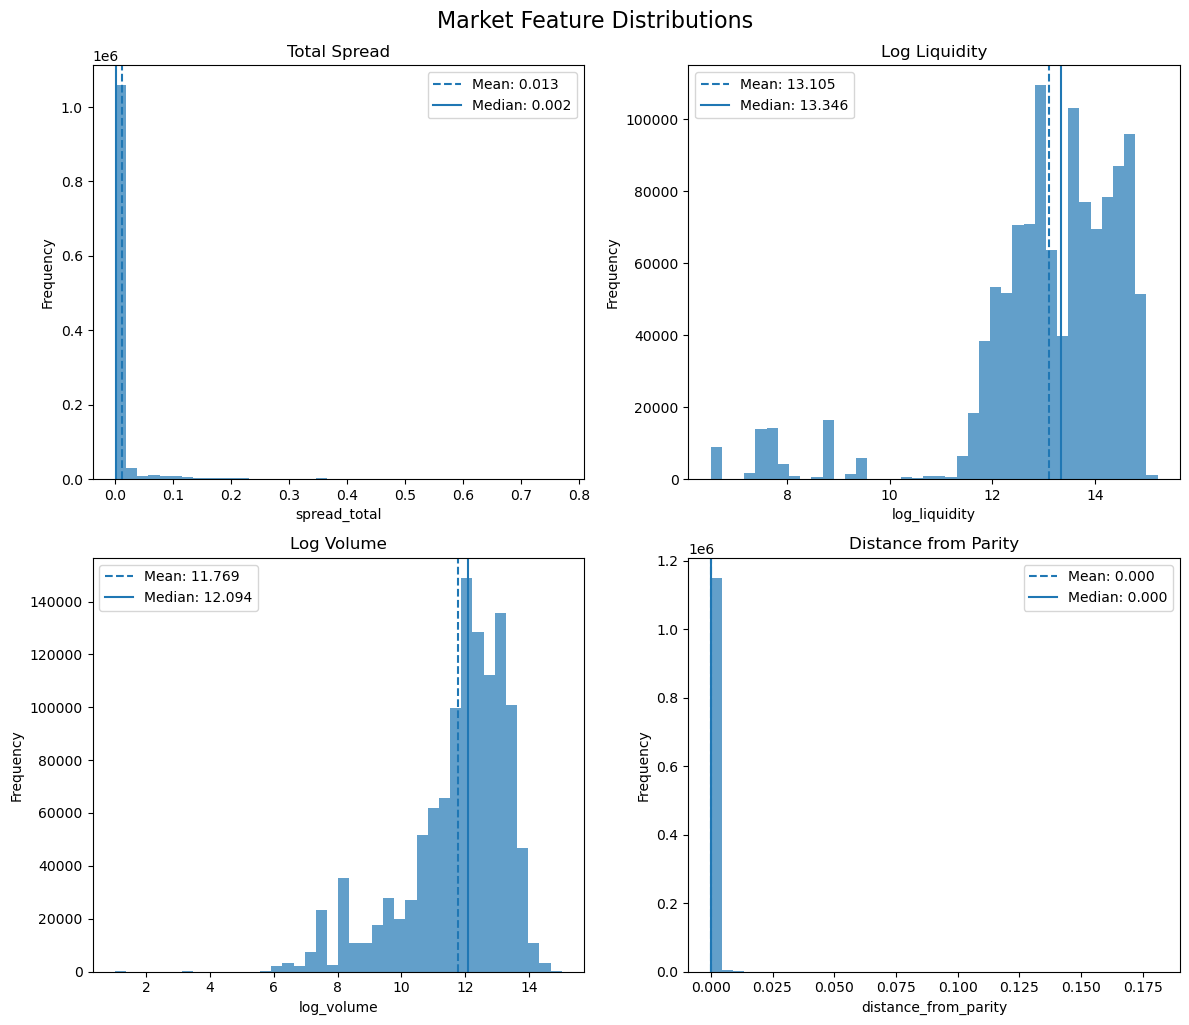

In [31]:
#limiting out na/not possible spread totals 
df = df[((df["spread_total"] <= 1) & (df["spread_total"] >= 0)) | (df["spread_total"].isna())]

# log values since large values
df["log_liquidity"] = np.log1p(df["liquidity_num"])
df["log_volume"] = np.log1p(df["volume_24hr"])

#variables to plot
variables = [
    'spread_total',
    'log_liquidity',
    'log_volume',
    'distance_from_parity'
]

titles = [
    'Total Spread',
    'Log Liquidity',
    'Log Volume',
    'Distance from Parity'
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, var, title in zip(axes.flat, variables, titles):
    
    data = df[var].dropna()
    ax.hist(data, bins=40, alpha=0.7)
    mean_val = data.mean()
    median_val = data.median()
    
    ax.axvline(mean_val, linestyle='--', label=f"Mean: {mean_val:.3f}")
    ax.axvline(median_val, linestyle='-', label=f"Median: {median_val:.3f}")
    
    ax.set_title(title)
    ax.set_xlabel(var)
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.suptitle('Market Feature Distributions', fontsize=16, y=1.02)
plt.show()

Note: Distance From Parity is almost 0 for all rows

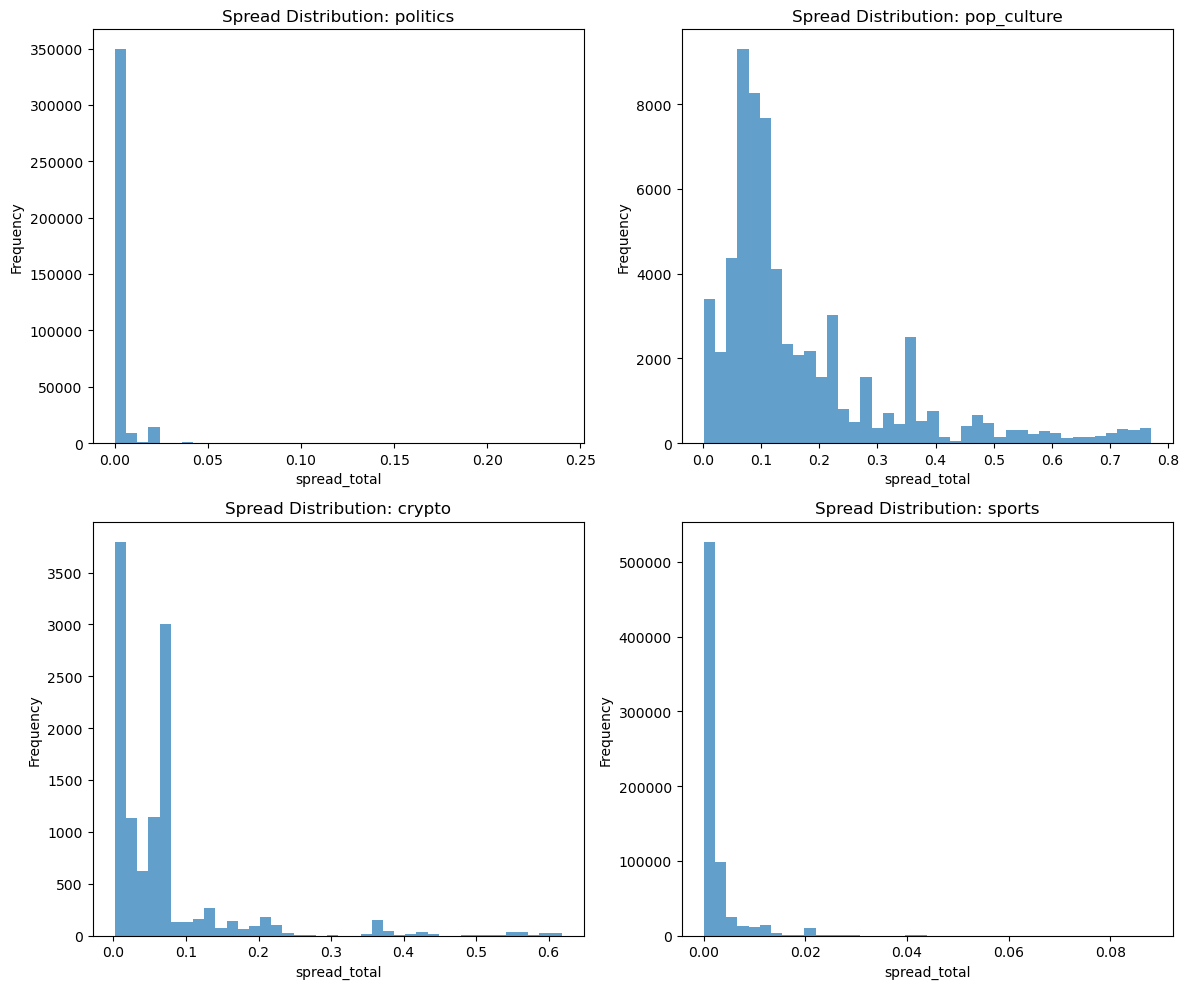

In [33]:
#distribution by category: 
categories = df['category_final'].dropna().unique()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, cat in zip(axes.flat, categories):
    subset = df[df["category_final"] == cat]
    
    ax.hist(subset["spread_total"].dropna(), bins=40, alpha=0.7)
    ax.set_title(f"Spread Distribution: {cat}")
    ax.set_xlabel("spread_total")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

sports: very tight distribution around 0, very efficient market, very liquid
geopolitics, politics, pop_colture: not a ton of data in these markets, seem less liquid but still lower spreads
crypto: looks to be an issue in the data here, spread varies a LOT or there are broken markets within crypto 

<Figure size 1000x600 with 0 Axes>

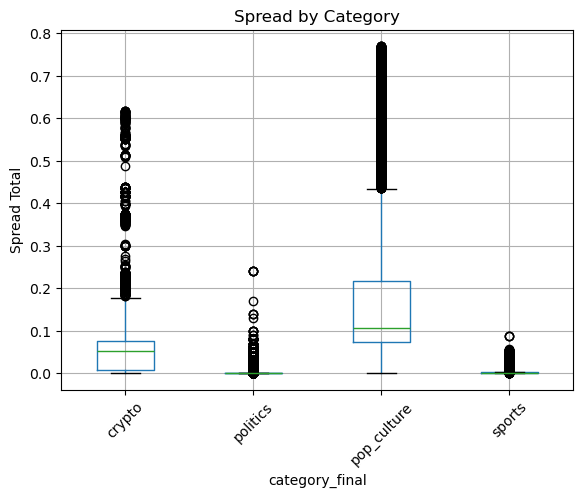

In [35]:
plt.figure(figsize=(10, 6))
df.boxplot(column="spread_total", by="category_final", rot=45)
plt.title("Spread by Category")
plt.suptitle("")
plt.ylabel("Spread Total")
plt.show()

# Step 5: Analyzing by Market Category

In [37]:
#compute per market metrics
market_stats = (
    df.groupby("market_id")
    .agg(
        category=("category_final", "first"),
        avg_volatility=("volatility_10", "mean"),
        avg_spread=("spread_total", "mean"),
        near_arb_rate=("near_arb", "mean"),
        liquidity=("liquidity_num", "mean")
    )
)

print(market_stats)

              category  avg_volatility  avg_spread  near_arb_rate  \
market_id                                                           
540816        politics        0.000000    0.020000       0.000000   
540817     pop_culture        0.002690    0.025881       0.003145   
540818     pop_culture        0.003145    0.036978       0.002747   
540819     pop_culture        0.000124    0.020094       0.000000   
540820        politics        0.000802    0.022322       0.003096   
...                ...             ...         ...            ...   
1357396         sports        0.003343    0.002965       1.000000   
1357399         sports        0.007026    0.020000       0.000000   
1357400         sports        0.013470    0.002222       1.000000   
1357401         sports        0.000000    0.002000       1.000000   
1455604       politics        0.000000    0.002000       1.000000   

              liquidity  
market_id                
540816     5.352427e+04  
540817     3.820084e+04 

In [38]:
#aggregate markets
category_volatility = (
    market_stats.groupby("category")
    .agg(
        avg_volatility=("avg_volatility", "mean"),
        avg_spread=("avg_spread", "mean"),
        avg_near_arb=("near_arb_rate", "mean"),
        avg_liquidity=("liquidity", "mean"),
        num_markets=("category", "count")
    )
    .sort_values("avg_volatility", ascending=False)
)

print(category_volatility)

             avg_volatility  avg_spread  avg_near_arb  avg_liquidity  \
category                                                               
pop_culture        0.010560    0.093001      0.104549  105171.930144   
sports             0.008708    0.005603      0.798865  802809.550454   
crypto             0.006912    0.028352      0.368838  233752.043702   
politics           0.001834    0.004923      0.856385  704412.228057   

             num_markets  
category                  
pop_culture           10  
sports               127  
crypto                 5  
politics             176  


In [39]:
#correlation between higher volatility markets and more near-arbitrage values?
df[["volatility_10", "near_arb"]].corr()

,volatility_10,near_arb
volatility_10,1.00000,-0.18592
near_arb,-0.18592,1.00000


Looking more at crypto:

In [41]:
crypto = df[df["category_final"] == "crypto"].copy()
crypto[~crypto["yes_ask"].between(0,1)]
crypto[~crypto["no_ask"].between(0,1)]
crypto["prob_sum"] = crypto["yes_mid"] + crypto["no_mid"]
crypto["prob_sum"].describe()

count    11509.000000
mean         0.999991
std          0.003233
min          0.888500
25%          1.000000
50%          1.000000
75%          1.000000
max          1.122500
Name: prob_sum, dtype: float64

In [42]:
pop_culture = df[df["category_final"] == "pop_culture"].copy()
pop_culture[~pop_culture["yes_ask"].between(0,1)]
pop_culture[~pop_culture["no_ask"].between(0,1)]
pop_culture["prob_sum"] = pop_culture["yes_mid"] + pop_culture["no_mid"]
pop_culture["prob_sum"].describe()

count    63680.000000
mean         0.999998
std          0.004192
min          0.852000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.181000
Name: prob_sum, dtype: float64

Conclusion: Crypto and pop_culture data seem valid, just very high variance, wide spread, and larger dislocations than other data(prob sum is ~1, no na values)

# Step 6: Developing ML Model

## Step 1: Organizing Table and Variables for ML

In [46]:
ml_df = df.sort_values(["market_id", "timestamp_utc"]).reset_index(drop=True).copy()

# forward fill market
ml_df["yes_bid"] = ml_df.groupby("market_id")["yes_bid"].ffill()

#replace missing last trade with mid price
ml_df["last_trade_price"] = ml_df["last_trade_price"].fillna(ml_df["mid_price"])

#make a continuous inefficiency target 
ml_df["buy_both_cost"] = ml_df["yes_ask"] + ml_df["no_ask"]
ml_df["inefficiency_score"] = 1 - ml_df["buy_both_cost"]

important_col = [
    "market_id", "timestamp_utc", "category_final",
    "yes_ask", "no_ask", "yes_bid", "no_bid",
    "spread_yes", "spread_no", "spread_total",
    "mid_sum", "distance_from_parity", "mid_price",
    "mid_return", "volatility_10", "spread_change",
    "spread_volatility", "volume_24hr", "liquidity_num",
    "buy_both_cost", "inefficiency_score"
]

ml_df = ml_df[important_col].dropna().copy()

In [47]:
# Check for missing values
print("Missing values per column:")
print(ml_df[important_col].isnull().sum())
print(f"\nTotal missing values: {ml_df[important_col].isnull().sum().sum()}")
print(f"\nRemaining Rows: {len(ml_df[important_col])}")

Missing values per column:
market_id               0
timestamp_utc           0
category_final          0
yes_ask                 0
no_ask                  0
yes_bid                 0
no_bid                  0
spread_yes              0
spread_no               0
spread_total            0
mid_sum                 0
distance_from_parity    0
mid_price               0
mid_return              0
volatility_10           0
spread_change           0
spread_volatility       0
volume_24hr             0
liquidity_num           0
buy_both_cost           0
inefficiency_score      0
dtype: int64

Total missing values: 0

Remaining Rows: 1153363


## Step 2: Defining Target Variable 
- "inefficiency score": 1- buy_both_cost

In [49]:
#target variable: because arbitrage is so rare, looking at when approaching arbitrage/market inefficiency
#shift ensures looking at future inefficiency in the market 
ml_df["target_inefficiency"] = (
    ml_df.groupby("market_id")["inefficiency_score"].shift(-3)
)

ml_df = ml_df.dropna(subset=["target_inefficiency"]).copy()

## Step 3: Dividing Data into Training, Validation, and Test

In [51]:
#create the market level table:
market_df = ml_df[["market_id", "category_final"]].drop_duplicates()
market_df = market_df.rename(columns={"category_final": "category"})
print(market_df)

         market_id     category
10          540816     politics
764         540817  pop_culture
1082        540818  pop_culture
1810        540819  pop_culture
3081        540820     politics
...            ...          ...
1156756    1357395       sports
1157386    1357396       sports
1157729    1357399       sports
1157788    1357400       sports
1157815    1357401       sports

[294 rows x 2 columns]


In [52]:
#create the market level table:
market_df = market_df[["market_id", "category"]].drop_duplicates()

#using sklearn to do stratified sampling so all groups have a proportional number of categories
#random seed for reproducability 
#first, splitting exactly 50% for training data
train_ids, temp_ids = train_test_split(
    market_df,
    test_size=0.5,
    stratify=market_df["category"],
    random_state=42
)

#then, splitting other 50 between validation and test
val_ids, test_ids = train_test_split(
    temp_ids,
    test_size=0.5,
    stratify=temp_ids["category"],
    random_state=42
)


In [53]:
#map ids back to train, val, test
train = ml_df[ml_df["market_id"].isin(train_ids["market_id"])]
val   = ml_df[ml_df["market_id"].isin(val_ids["market_id"])]
test  = ml_df[ml_df["market_id"].isin(test_ids["market_id"])]

In [54]:
#one hot encoding for category names
train = pd.get_dummies(train, columns=["category_final"], drop_first=True)
val   = pd.get_dummies(val, columns=["category_final"], drop_first=True)
test  = pd.get_dummies(test, columns=["category_final"], drop_first=True)

train, val = train.align(val, join="left", axis=1, fill_value=0)
train, test = train.align(test, join="left", axis=1, fill_value=0)

val = val.reindex(columns=train.columns, fill_value=0)
test = test.reindex(columns=train.columns, fill_value=0)

In [55]:
feature_cols = [
    "spread_change",
    "spread_volatility",
    "volatility_10",
    "mid_return",
    "category_final_sports", 
    "category_final_pop_culture",
    "category_final_politics"
]

x_train = train[feature_cols]
y_train = train["target_inefficiency"]

x_val = val[feature_cols]
y_val = val["target_inefficiency"]

x_test = test[feature_cols]
y_test = test["target_inefficiency"]

print(len(x_train))

654922


In [56]:
print(x_train.columns)

Index(['spread_change', 'spread_volatility', 'volatility_10', 'mid_return',
       'category_final_sports', 'category_final_pop_culture',
       'category_final_politics'],
      dtype='object')


In [57]:
x_train_df = train[feature_cols]
x_test_df  = test[feature_cols]

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_df)
x_test_scaled  = scaler.transform(x_test_df)

### Looking at Correlation to see what variables to emit

In [59]:
#looking at correlation of variables
#Note! model has high condition number, but the only high correlation values is between pop_culture and spread_total
#category is capturing spread behavior
corr_matrix = x_train.corr()
print(corr_matrix)

                            spread_change  spread_volatility  volatility_10  \
spread_change                    1.000000           0.032793       0.017805   
spread_volatility                0.032793           1.000000       0.321596   
volatility_10                    0.017805           0.321596       1.000000   
mid_return                       0.014467           0.009122       0.060857   
category_final_sports            0.000026          -0.123471      -0.030904   
category_final_pop_culture      -0.000246           0.360578       0.108755   
category_final_politics          0.000037          -0.063479      -0.018372   

                            mid_return  category_final_sports  \
spread_change                 0.014467               0.000026   
spread_volatility             0.009122              -0.123471   
volatility_10                 0.060857              -0.030904   
mid_return                    1.000000              -0.000078   
category_final_sports        -0.000078    

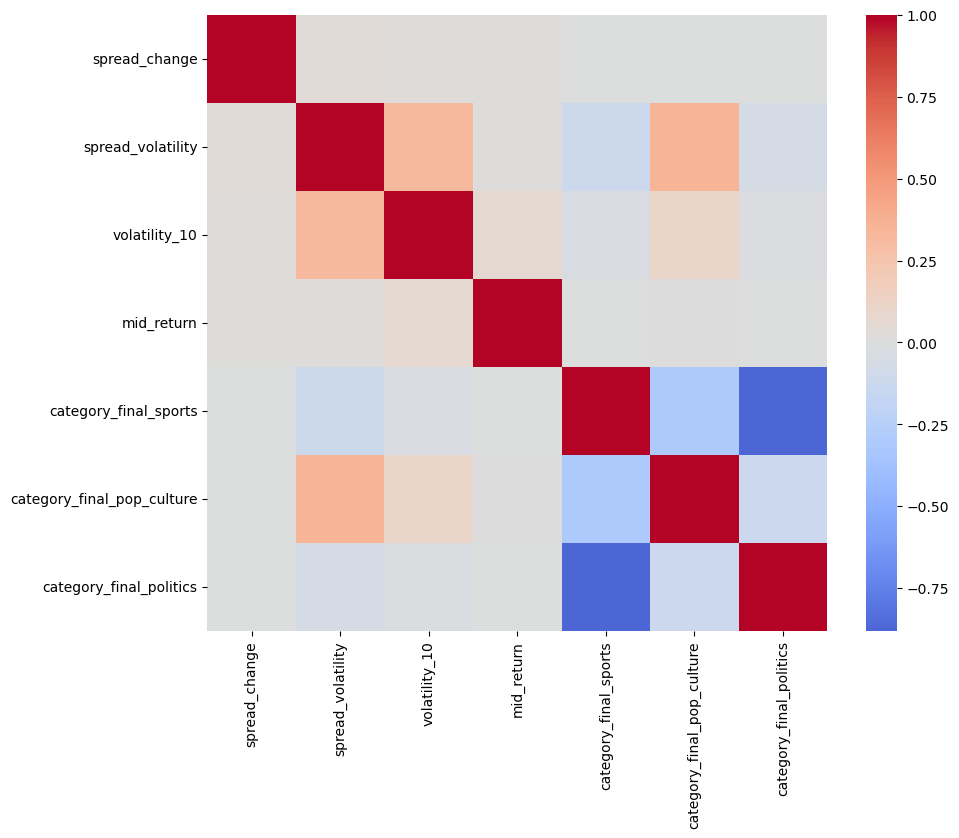

In [60]:
plt.figure(figsize=(10,8))
sns.heatmap(x_train.corr(), cmap="coolwarm", center=0)
plt.show()

In [61]:
X = x_train.astype(float)

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data.sort_values(by="VIF", ascending=False))

                      feature       VIF
1           spread_volatility  1.304432
2               volatility_10  1.209162
5  category_final_pop_culture  1.173792
4       category_final_sports  1.046254
6     category_final_politics  1.017015
3                  mid_return  1.004054
0               spread_change  1.001485


## Step 4: Training/Evaluating Models 
- For this data, I chose to use a random forest AND logistic regression. Other high accuracy pre-published arbitrage prediction models used these two algorithms, so I chose to focus on these two for my project.
- Here is an example: https://onlinelibrary.wiley.com/doi/full/10.1002/nem.70030
- Resource: https://www.geeksforgeeks.org/machine-learning/random-forest-hyperparameter-tuning-in-python/

In [63]:
#uncomment to run- takes few hours to run with kfolds=5
'''
results = []
best_model = None
best_params = None
best_rmse = float("inf")

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 0.5, 1.0],
    'bootstrap': [True],
    'max_samples': [0.5, 0.8]
}

param_list = list(ParameterGrid(param_grid))
kf = KFold(n_splits=5, shuffle=True, random_state=42)


for i in range(len(param_list)):
    params = param_list[i]
    model = RandomForestRegressor(
        **params, 
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(x_train, y_train)
    y_val_pred = model.predict(x_val)

    #update: 
    #maximizing negative rmse
    cv_rmse_scores = -cross_val_score(
        model,
        x_train,
        y_train,
        cv=kf,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    #maximizing raw r2 value
    cv_r2_scores = cross_val_score(
        model,
        x_train,
        y_train,
        cv=kf,
        scoring="r2",
        n_jobs=-1
    )

    rmse = cv_rmse_scores.mean()
    r2 = cv_r2_scores.mean()

    results.append({
        **params,
        "valid_rmse": rmse,
        "valid_r2": r2
    })

    if rmse < best_rmse:
        best_rmse = rmse
        best_params = params 
        best_model = model 
        
print(f"Best Parameters: {best_params}")
print(f"Best Validation RMSE: {best_rmse}")

results_df = pd.DataFrame(results).sort_values("valid_rmse")
'''

'\nresults = []\nbest_model = None\nbest_params = None\nbest_rmse = float("inf")\n\nparam_grid = {\n    \'n_estimators\': [200, 400],\n    \'max_depth\': [5, 10, None],\n    \'min_samples_split\': [2, 5, 10, 20],\n    \'min_samples_leaf\': [1, 2, 5],\n    \'max_features\': [\'sqrt\', 0.5, 1.0],\n    \'bootstrap\': [True],\n    \'max_samples\': [0.5, 0.8]\n}\n\nparam_list = list(ParameterGrid(param_grid))\nkf = KFold(n_splits=5, shuffle=True, random_state=42)\n\n\nfor i in range(len(param_list)):\n    params = param_list[i]\n    model = RandomForestRegressor(\n        **params, \n        random_state=42,\n        n_jobs=-1\n    )\n\n    model.fit(x_train, y_train)\n    y_val_pred = model.predict(x_val)\n\n    #update: \n    #maximizing negative rmse\n    cv_rmse_scores = -cross_val_score(\n        model,\n        x_train,\n        y_train,\n        cv=kf,\n        scoring="neg_root_mean_squared_error",\n        n_jobs=-1\n    )\n\n    #maximizing raw r2 value\n    cv_r2_scores = cross_v

In [64]:
#best model: 
model = RandomForestRegressor(
    max_depth=5,
    min_samples_leaf=5,
    min_samples_split=20,
    max_samples=0.5
)

model.fit(x_train, y_train)

y_val_pred = model.predict(x_val)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2 = r2_score(y_val, y_val_pred)

## Model works best when inefficiency is larger!
### Validation set:
- Targets tightly clustered near 0
- Hard to explain variance → lower R²
### Test set:
- More spread out (bigger std)
- Easier to “explain variance” → higher R²
### Train set: 
- In between the two

In [66]:
print("Train std:", y_train.std())
print("Validation std:", y_val.std())
print("Test std:", y_test.std())

Train std: 0.02925152564154972
Validation std: 0.01056234498740284
Test std: 0.031339803930882926


In [67]:
y_train_pred = model.predict(x_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

In [68]:
print(f"Train RMSE: {rmse}")
print(f"Train r^2: {r2}")
print(f"Normalized Train RMSE: {rmse/y_train.std()}")

Train RMSE: 0.0076657702524866225
Train r^2: 0.4732645819503325
Normalized Train RMSE: 0.26206394655866905


In [69]:
print(f"Validation RMSE: {rmse}")
print(f"Validation r^2: {r2}")
print(f"Normalized Validation RMSE: {rmse/y_val.std()}")

Validation RMSE: 0.0076657702524866225
Validation r^2: 0.4732645819503325
Normalized Validation RMSE: 0.7257640478160094


In [70]:
y_test_pred = model.predict(x_test)
rmse2 = np.sqrt(mean_squared_error(y_test, y_test_pred))
r22 = r2_score(y_test, y_test_pred)

In [71]:
print(f"Test RMSE: {rmse2}")
print(f"Test r^2: {r22}")
print(f"Normalized Test RMSE: {rmse2/y_test.std()}")

Test RMSE: 0.019447455190668154
Test r^2: 0.6149342414538183
Normalized Test RMSE: 0.6205353177562227


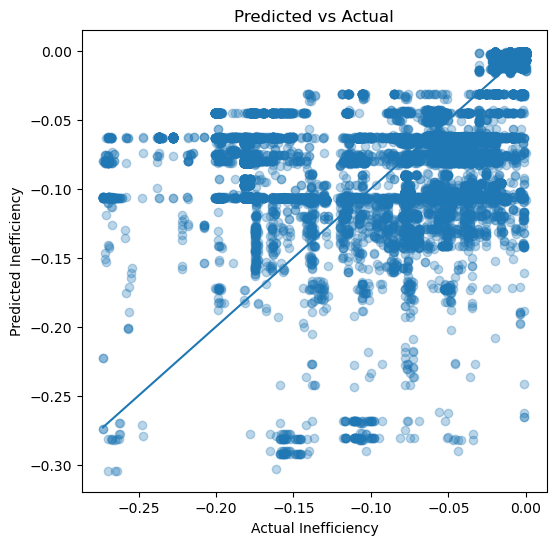

In [72]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred, alpha=0.3)
plt.xlabel("Actual Inefficiency")
plt.ylabel("Predicted Inefficiency")
plt.title("Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.show()

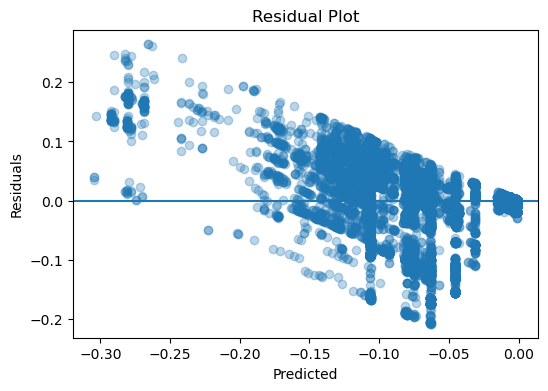

In [73]:
residuals = y_test - y_test_pred

plt.figure(figsize=(6,4))
plt.scatter(y_test_pred, residuals, alpha=0.3)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

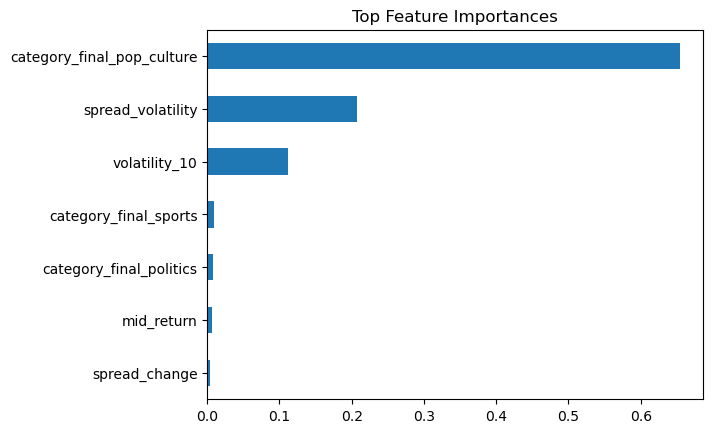

In [74]:
importance = pd.Series(
    model.feature_importances_,
    index=x_train.columns
).sort_values(ascending=False)

importance.head(15).plot(kind="barh")
plt.title("Top Feature Importances")
plt.gca().invert_yaxis()
plt.show()

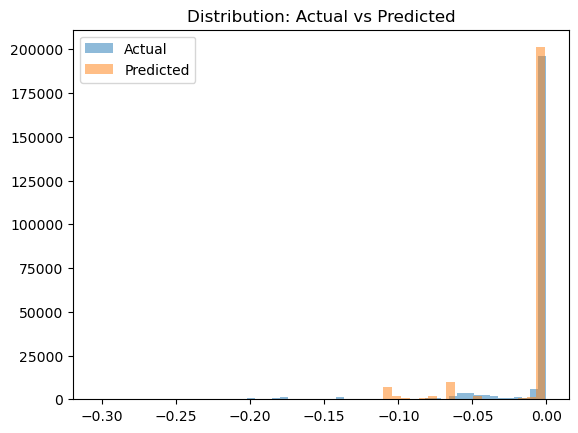

In [75]:
plt.hist(y_test, bins=50, alpha=0.5, label="Actual")
plt.hist(y_test_pred, bins=50, alpha=0.5, label="Predicted")
plt.legend()
plt.title("Distribution: Actual vs Predicted")
plt.show()

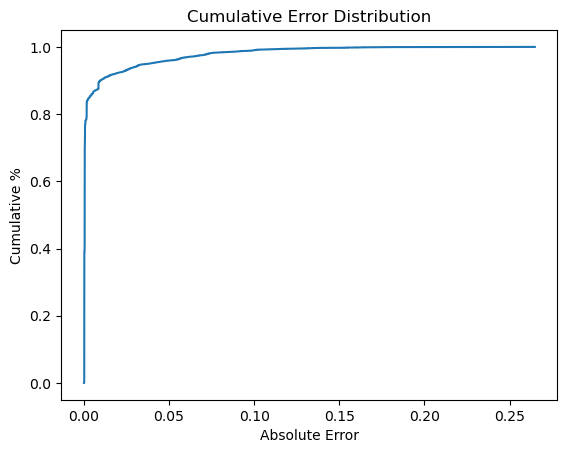

In [76]:
sorted_errors = np.sort(np.abs(residuals))
cum = np.arange(len(sorted_errors)) / len(sorted_errors)

plt.plot(sorted_errors, cum)
plt.xlabel("Absolute Error")
plt.ylabel("Cumulative %")
plt.title("Cumulative Error Distribution")
plt.show()